# Import Depedencies

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
PaletteBright = sns.color_palette('bright')
PaletteHls = sns.color_palette('hls', 8)
PalettePaired = sns.color_palette('Paired')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'Arial', 'font.size': 10,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'axes.labelweight': 'semibold', 'axes.titlepad': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'grid.linewidth': 0.8, 'grid.color': '#808080',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.linewidth': 1.2,
    'figure.autolayout': True
})

output_dir = '../image'
os.makedirs(output_dir, exist_ok=True)

print('Setup Selesai')

Setup Selesai


# Load Data

In [2]:
def load_data(path):
    for dirname, _, filenames in os.walk('../data'):
        if path in filenames:
            return os.path.join(dirname, path)

df = pd.read_csv(load_data('dataset_analisis_pantai_kenjeran.csv'))
# df['Transect_ID'] = df['Transect_ID'] - 1
df['Transect_ID'] = df['Transect_ID'].astype(str)
df['DATE_'] = pd.to_datetime(df['DATE_'])
df[['Lag_1', 'Lag_2', 'Lag_3']] = df[['Lag_1', 'Lag_2', 'Lag_3']].fillna(0)
df

,Transect_ID,Tahun,DATE_,Shoreline_Distance,Lag_1,Lag_2,Lag_3,Longitude_UTM,Latitude_UTM,azimuth,tcd,lrr,epr,nsm,sce,shrcount
0,2,2015,2015-01-01,175.033770,0.000000,0.000000,0.000000,697516.355020,9.201540e+06,73.41,50.0,0.002941,0.006445,0.064449,0.064509,11
1,2,2016,2016-01-01,175.098218,175.033770,0.000000,0.000000,697516.441562,9.201540e+06,73.41,50.0,0.002941,0.006445,0.064449,0.064509,11
2,2,2017,2017-01-01,175.098007,175.098218,175.033770,0.000000,697516.441774,9.201540e+06,73.41,50.0,0.002941,0.006445,0.064449,0.064509,11
3,2,2018,2018-01-01,175.097883,175.098007,175.098218,175.033770,697516.441898,9.201540e+06,73.41,50.0,0.002941,0.006445,0.064449,0.064509,11
4,2,2019,2019-01-01,175.098278,175.097883,175.098007,175.098218,697516.441502,9.201540e+06,73.41,50.0,0.002941,0.006445,0.064449,0.064509,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1126,107,2019,2019-01-01,105.064905,139.567095,70.562714,1.558678,699302.176292,9.198330e+06,29.60,5300.0,20.747377,25.300851,253.008509,253.008509,8
1127,107,2020,2020-01-01,185.569778,105.064905,139.567095,70.562714,699341.938472,9.198400e+06,29.60,5300.0,20.747377,25.300851,253.008509,253.008509,8
1128,107,2021,2021-01-01,139.567011,185.569778,105.064905,139.567095,699319.217235,9.198360e+06,29.60,5300.0,20.747377,25.300851,253.008509,253.008509,8
1129,107,2022,2022-01-01,139.567040,139.567011,185.569778,105.064905,699319.217249,9.198360e+06,29.60,5300.0,20.747377,25.300851,253.008509,253.008509,8


# Shoreline Analysis

## Net Shoreline Movement Analysis

In [3]:
# Add Feature NSM Category
def nsm_kategori(nsm):
    if nsm > 0.5:
        return 'Akresi'
    elif nsm < -0.5:
        return 'Abrasi'
    else:
        return 'Stabil'

df['nsm_category'] = df['nsm'].apply(nsm_kategori)
jumlah = df['nsm_category'].value_counts()
percent = round(df['nsm_category'].value_counts(normalize=True) * 100, 2)
print(percent)

# Add Feature Segmen per Some Transect
tcd_min = df['tcd'].min()
tcd_max = df['tcd'].max()
transect_unique = df['Transect_ID'].nunique()
amount_class = int(np.ceil(1 + 3.3 * np.log10(transect_unique)))
def segmen(tcd):
    diff = tcd_max - tcd_min
    k = diff / amount_class
    return int((tcd - tcd_min) // (k)) + 1
df['segmen'] = df['tcd'].apply(segmen).astype(str)
df['segmen'] = df['segmen'].clip(upper=str(amount_class))

nsm_category
Akresi    64.28
Abrasi    20.16
Stabil    15.56
Name: proportion, dtype: float64


In [4]:
max_transek = df.loc[
    df['nsm'].idxmax(),
    ['Transect_ID', 'nsm', 'segmen']
].to_dict()
min_transek = df.loc[
    df['nsm'].idxmin(),
    ['Transect_ID', 'nsm', 'segmen']
].to_dict()

print(max_transek)
print(min_transek)
print()

for cat in df['nsm_category'].unique():
    mean_nsm = df[df['nsm_category'] == cat]['nsm']
    print(f'Rata-rata {cat}:', mean_nsm.mean())

{'Transect_ID': '106', 'nsm': 295.947601, 'segmen': '8'}
{'Transect_ID': '69', 'nsm': -211.014929, 'segmen': '6'}

Rata-rata Stabil: 0.0040325000000000005
Rata-rata Akresi: 66.14427342365887
Rata-rata Abrasi: -27.963294078947367


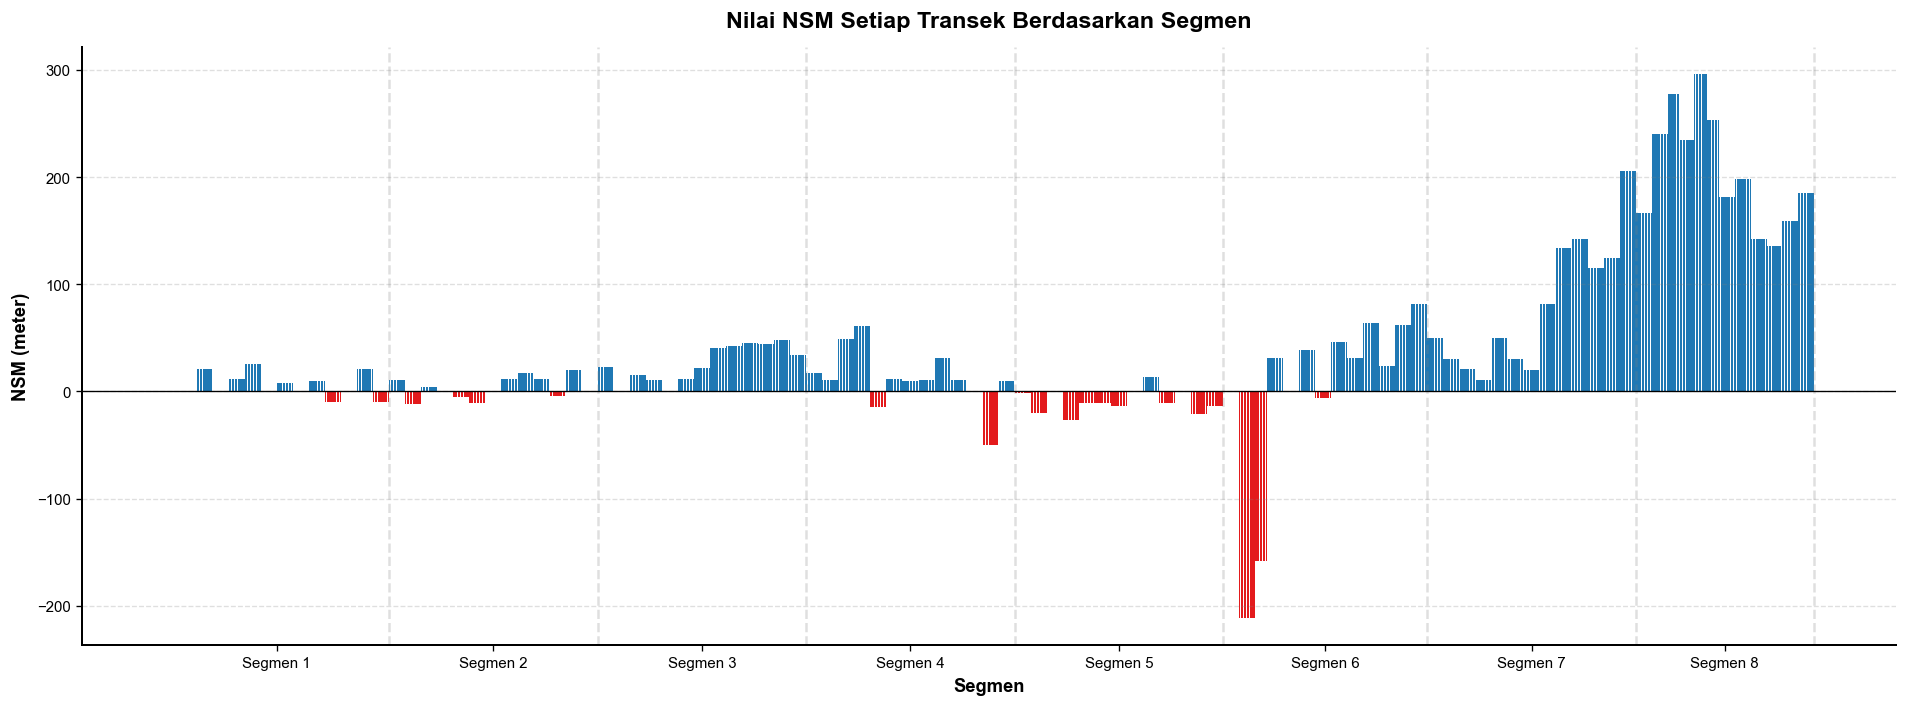

In [5]:
plot_df = df.sort_values(['segmen', 'Transect_ID'])

x = np.arange(len(plot_df))
colors = [PalettePaired[5] if nsm < 0.5 else PalettePaired[1] for nsm in plot_df["nsm"]]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x, plot_df['nsm'], width=0.8, color=colors)

for _, g in plot_df.groupby('segmen'):
    ax.axvline(g.index.max() + 0.5, color='gray', linestyle='--', alpha=0.25)

segments_center = (
    plot_df.groupby('segmen').apply(lambda x: (x.index.min() + x.index.max()) / 2)
)

ax.set_xticks(segments_center.values, [f'Segmen {i}' for i in segments_center.index])

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title("Nilai NSM Setiap Transek Berdasarkan Segmen")
ax.set_xlabel("Segmen")
ax.set_ylabel("NSM (meter)")
ax.grid(axis='x')
plt.savefig(os.path.join(output_dir, 'nsm_per_transect.png'), dpi=300, bbox_inches='tight')
plt.show()

# Shoreline Change Envelope Analysis

In [6]:
min_sce = df.loc[
    df['sce'].idxmin(),
    ['Transect_ID', 'segmen', 'Tahun', 'sce']
].to_dict()
print(min_sce)

max_sce = df.loc[
    df['sce'].idxmax(),
    ['Transect_ID', 'segmen', 'Tahun', 'sce']
].to_dict()
print(max_sce)

mean_sce = df['sce'].mean()
print('Mean SCE:', mean_sce)

{'Transect_ID': '4', 'segmen': '1', 'Tahun': 2015, 'sce': 5.7e-05}
{'Transect_ID': '101', 'segmen': '8', 'Tahun': 2015, 'sce': 296.575752}
Mean SCE: 73.60420757471265


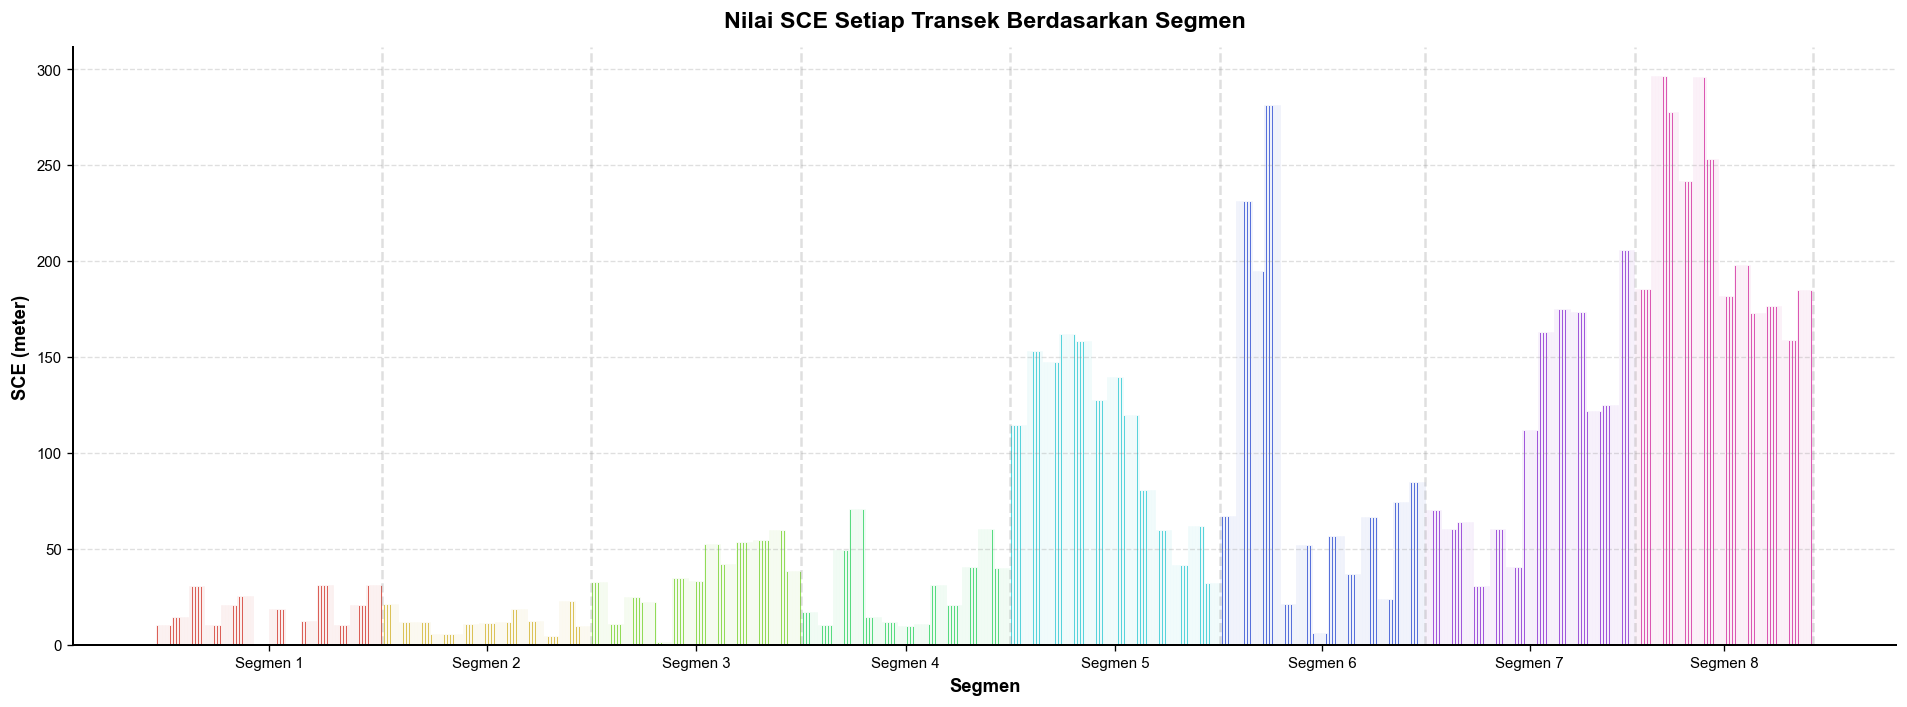

In [7]:
plot_df = df.sort_values(['segmen', 'Transect_ID']).reset_index(drop=True)
x = np.arange(len(plot_df))
segment_map = {seg: PaletteHls[i] for i, seg in enumerate(sorted(plot_df['segmen'].unique()))}
bar_colors = plot_df['segmen'].map(segment_map)

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(
    x, plot_df['sce'],
    color=bar_colors, width=0.85,
    edgecolor='white', linewidth=0.5
)

for _, g in plot_df.groupby('segmen'):
    ax.axvline(g.index.max() + 0.5, color='gray', linestyle='--', alpha=0.25)

segmen_centers = (
    plot_df.groupby('segmen').apply(lambda x: (x.index.min() + x.index.max()) / 2)
)

ax.set_xticks(segmen_centers.values, [f'Segmen {i}' for i in segmen_centers.index])

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title("Nilai SCE Setiap Transek Berdasarkan Segmen")
ax.set_xlabel("Segmen")
ax.set_ylabel("SCE (meter)")
ax.grid(axis='x')
plt.savefig(os.path.join(output_dir, 'sce_per_transect.png'), dpi=300, bbox_inches='tight')
plt.show()

## End Point Rate Analysis

In [8]:
min_epr = df.loc[
    df['epr'].idxmin(),
    ['Transect_ID', 'segmen', 'epr']
]
print(min_epr)
max_epr = df.loc[
    df['epr'].idxmax(),
    ['Transect_ID', 'segmen', 'epr']
]
print(max_epr)

for cat in df['nsm_category'].unique():
    mean_epr = df[df['nsm_category'] == cat]['epr']
    print(f'Rata-rata {cat}:', mean_epr.mean())

Transect_ID           69
segmen                 6
epr           -21.101493
Name: 737, dtype: object
Transect_ID         106
segmen                8
epr            36.99345
Name: 1114, dtype: object
Rata-rata Stabil: 0.00040318749999999995
Rata-rata Akresi: 6.706020469050894
Rata-rata Abrasi: -2.8578959692982457


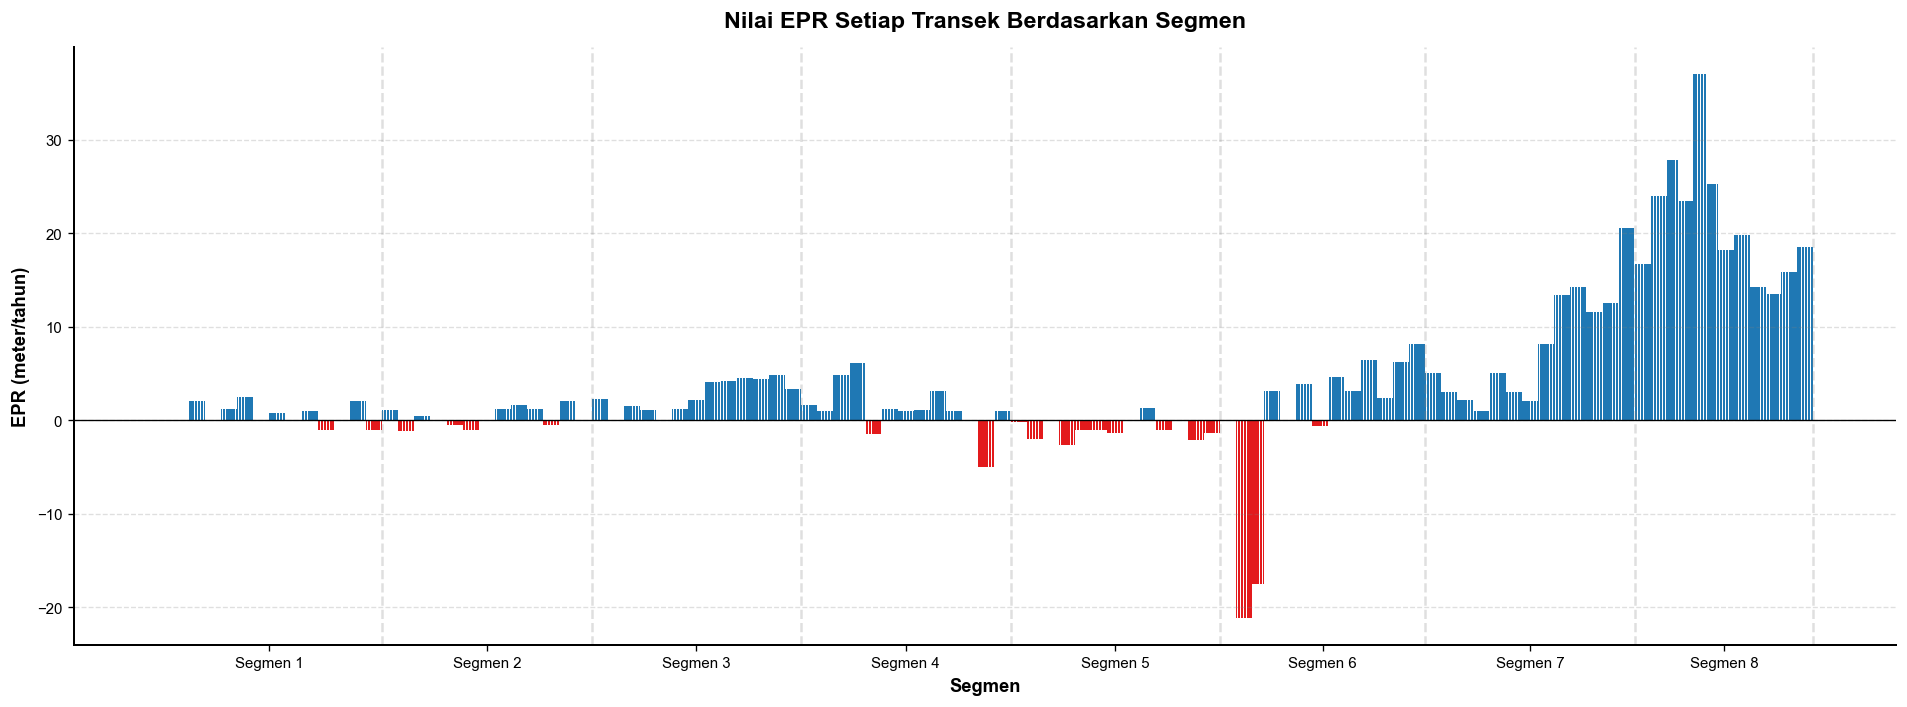

In [9]:
plot_df = df.sort_values(['segmen', 'Transect_ID'])

x = np.arange(len(plot_df))
colors = [PalettePaired[5] if epr < 0 else PalettePaired[1] for epr in plot_df["epr"]]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x, plot_df['epr'], width=0.8, color=colors)

for _, g in plot_df.groupby('segmen'):
    ax.axvline(g.index.max() + 0.5, color='gray', linestyle='--', alpha=0.25)

segments_center = (
    plot_df.groupby('segmen').apply(lambda x: (x.index.min() + x.index.max()) / 2)
)

ax.set_xticks(segments_center.values, [f'Segmen {i}' for i in segments_center.index])

ax.axhline(0, color='black', linewidth=0.8)

ax.set_title("Nilai EPR Setiap Transek Berdasarkan Segmen")
ax.set_xlabel("Segmen")
ax.set_ylabel("EPR (meter/tahun)")
ax.grid(axis='x')
plt.savefig(os.path.join(output_dir, 'epr_per_transect.png'), dpi=300, bbox_inches='tight')
plt.show()

## Linear Regression Rate Analysis

In [10]:
min_lrr = df.loc[
    df['lrr'].idxmin(),
    ['Transect_ID', 'segmen', 'lrr']
]
print(min_lrr)
max_lrr = df.loc[
    df['lrr'].idxmax(),
    ['Transect_ID', 'segmen', 'lrr']
]
print(max_lrr)

mean_lrr_accretion = df[df['lrr'] > 0]['lrr'].mean()
print('Mean of Acrretion:', mean_lrr_accretion)
mean_lrr_abration = df[df['lrr'] < 0]['lrr'].mean()
print('Mean of Abration:', mean_lrr_abration)

Transect_ID           70
segmen                 6
lrr           -11.714634
Name: 748, dtype: object
Transect_ID          102
segmen                 8
lrr            22.226587
Name: 1096, dtype: object
Mean of Acrretion: 5.615370083753784
Mean of Abration: -1.5641922071428576
